# The phase current and the gate switches, live

Two thirds the phase currents, one third the switches: one graph per leg
with its high side and low side, all on one time base. Every point on
every axis comes from the SAME record, so a current and the switching
that produced it line up by construction rather than by two runs being
started close together.

**Why duties and not levels.** A pin in a record is the fraction of the
window it was high, because a level sampled once and decimated is
aliased by construction - KEEPALIVE toggles at ~100 kHz and read as a
coin toss. At 50 kHz PWM a gate's duty IS the modulation.

**The axis is fixed and the data scrolls.** `frames()` indexes on seconds
before now, so the newest sample sits at 0 and older ones trail off to
the left until they leave the window. Sliding the limits instead makes
the ticks crawl and the eye follows them rather than the trace.

Live, every frame redraws; checked in here, the loop runs to its end
and the LAST frame is the figure. `BUFFER` seconds are held behind the
`WINDOW` seconds shown, to pan back over.

In [1]:
import os
import sys

from pathlib import Path

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))

from coaxial import Coaxial63100                            # noqa: E402

try:
    from matplotlib import pyplot
except ImportError:
    print('this example needs pandas and matplotlib: '
          'pip install pandas matplotlib')
    raise SystemExit(0)

SIMULATED = True                    # False at the bench
PORT = 'COM4'
SECONDS = 6.0                       # how long the loop runs
WINDOW = 2.0                        # seconds on screen
BUFFER = 10.0                       # seconds kept behind the window

1000 records on screen (2.0 s), 1095 buffered behind them (10 s)
host peak 0, dropped 0, lost 0
      Phase U (A)  Phase V (A)  Phase W (A)
mean       13.873      -57.903        4.342
std        40.621       36.428       42.628
min       -48.255     -107.865      -54.881
max        65.938        6.021       59.411


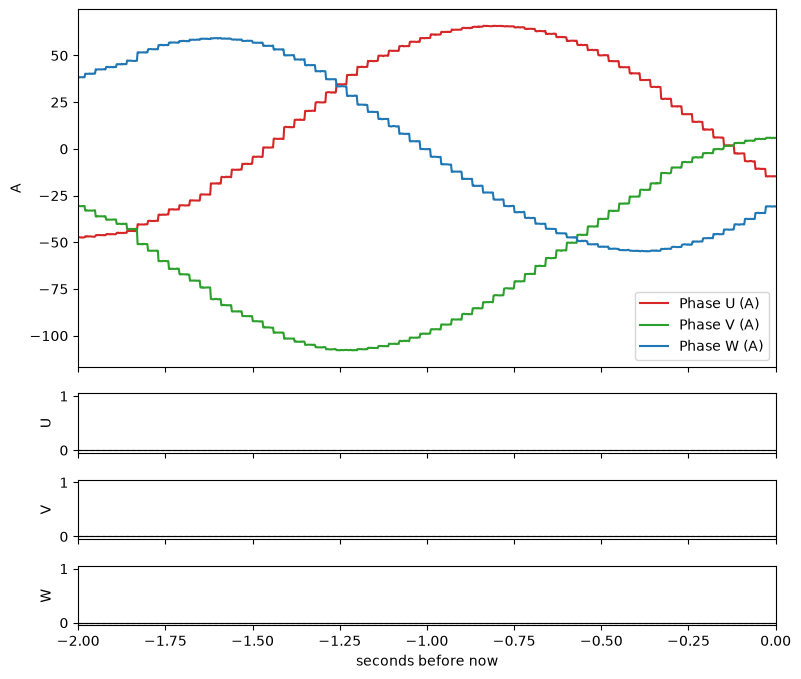

In [2]:
figure, axes = pyplot.subplots(4, 1, sharex=True, figsize=(9, 8),
                               gridspec_kw={'height_ratios': [6, 1, 1, 1]})
amps_ax, leg_axes = axes[0], axes[1:]

with Coaxial63100(port=PORT, simulated_device=SIMULATED) as device:
    device.set_time_from_pc()
    daq = device.daq
    daq.enable()               # powers the analog front end
    daq.configure_buffer(20000)
    daq.configure('phaseU', 'phaseV', 'phaseW', 'AFE_ON', sample_rate=500)

    with daq:
        for df in daq.frames(window=WINDOW, buffer=BUFFER,
                             seconds=SECONDS, scaled=True):
            for axis in axes:
                axis.clear()

            # The frame already says what each column is: `scaled` names the
            # currents in amperes, and the gates carry the board's own pin
            # names. Sorted, the high side comes before the low - H before
            # L - so the solid line is always HS.
            df.filter(like=' (A)').plot(
                ax=amps_ax, color=['tab:red', 'tab:green', 'tab:blue'])
            amps_ax.set(ylabel='A', xlim=(-WINDOW, 0))

            for axis, leg in zip(leg_axes, 'UVW'):
                df.filter(like='PWM' + leg).sort_index(axis=1).plot(
                    ax=axis, legend=False, color='black',
                    style=['-', '--'], linewidth=0.8)
                axis.set(ylabel=leg, ylim=(-0.05, 1.05), yticks=[0, 1])

            leg_axes[-1].set_xlabel('seconds before now')

    held = daq.history(scaled=True)      # the buffer behind the window
    buffered = daq.buffered

print('%d records on screen (%.1f s), %d buffered behind them (%.0f s)'
      % (len(df), WINDOW, len(held), BUFFER))
print('host peak %d, dropped %d, lost %d'
      % (buffered['peak'], buffered['dropped'], buffered['lost']))
print(held.filter(like=' (A)').describe().loc[['mean', 'std', 'min', 'max']]
      .to_string(float_format='%.3f'))